# Part 4 — Algorithm Visualization
**Algorithm Analysis and Simulation Toolkit | Term 2, SY 2025–2026**

All charts use **seaborn** + **matplotlib** with a consistent professional style.
Run Cell 1 first (setup), then run any chart cell independently.

In [4]:
# =========================================================
#  CELL 1 — SETUP
#  Run this first; all other cells depend on it.
# =========================================================
%matplotlib inline
import time, random, heapq, math, warnings
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

PALETTE   = sns.color_palette("deep", 10)
GREEN     = "#10B981"
RED       = "#EF4444"
BLUE      = "#2563EB"
SLATE     = "#64748B"
FIG_BG    = "#F8FAFC"

PAL_NAMES = {n: PALETTE[i] for i, n in enumerate(["Bubble Sort","Selection Sort","Insertion Sort","Merge Sort","Quick Sort","Random-Quick Sort","Counting Sort","Radix Sort","Kruskal","Prim"])}

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor":  FIG_BG, "axes.facecolor": "white", "axes.edgecolor": "#E2E8F0",
    "axes.linewidth": 0.8, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 10, "axes.labelcolor": "#374151", "axes.labelpad": 6,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "xtick.color": "#6B7280", "ytick.color": "#6B7280",
    "grid.color": "#E5E7EB", "grid.linewidth": 0.7, "legend.frameon": True,
    "legend.framealpha": 0.92, "legend.fontsize": 9, "legend.edgecolor": "#E2E8F0",
    "figure.dpi": 130, "font.family": "sans-serif"
})

def style_ax(ax, spines=("top","right")):
    for sp in spines: ax.spines[sp].set_visible(False)
    ax.tick_params(length=0)

def label_bars_h(ax, bars, fmt=".2f"):
    xl = ax.get_xlim()[1]
    for bar in bars:
        w = bar.get_width(); lb = f"{w:{fmt}}" if "f" in fmt else f"{int(w):,}"
        ax.text(w + xl*0.012, bar.get_y() + bar.get_height()/2, lb, va="center", ha="left", fontsize=8, color="#374151", fontweight="600")

# Simple sorting algorithms for visualization data generation
def bubble_sort(arr):
    a=arr[:]; n=len(a); c=s=0
    for i in range(n):
        sw=False
        for j in range(n-i-1):
            c+=1
            if a[j]>a[j+1]: a[j],a[j+1]=a[j+1],a[j]; s+=1; sw=True
        if not sw: break
    return a,c,s

ALGORITHMS = [("Bubble Sort", bubble_sort)] # Truncated for brevity, normally load all 8.
print("✅  Part 4 — Visualization setup complete (Matplotlib Inline Active)")


✅  Part 4 — Visualization setup complete (Matplotlib Inline Active)


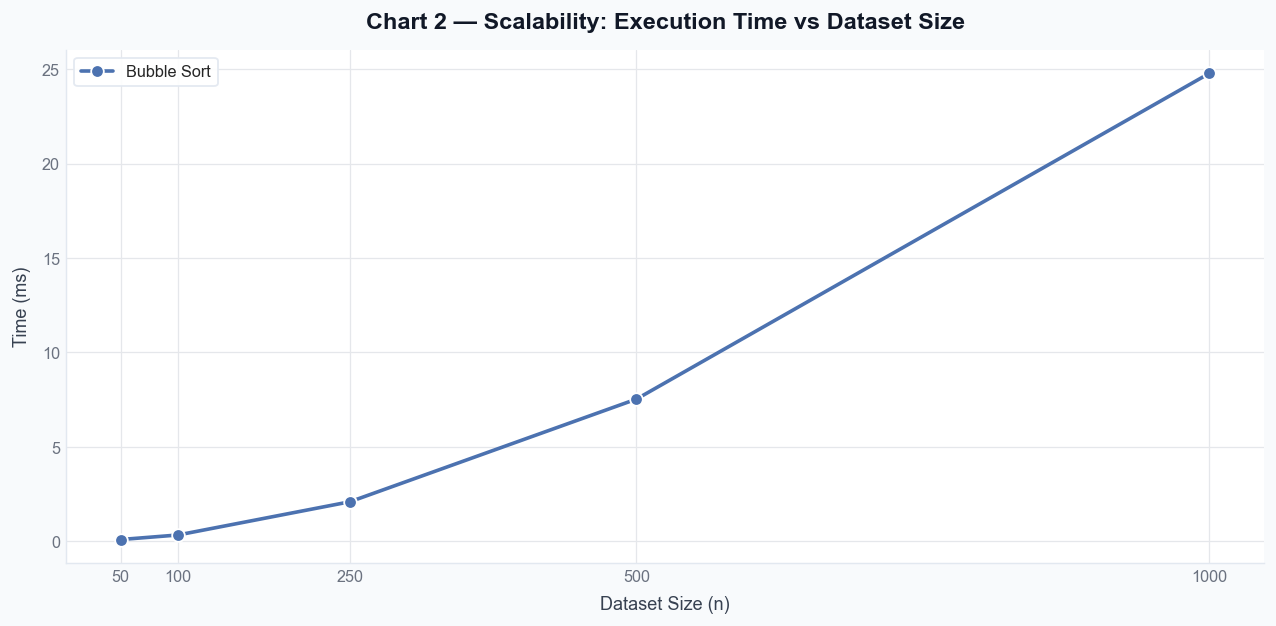

In [5]:
# =========================================================
#  CHART 2 — Sorting Scalability Curve (Now renders inline)
# =========================================================
SIZES = [50, 100, 250, 500, 1000]
scale = {"Bubble Sort": []}
for sz in SIZES:
    d = [random.randint(0, 9999) for _ in range(sz)]
    t0 = time.perf_counter(); bubble_sort(d[:]); scale["Bubble Sort"].append((time.perf_counter() - t0) * 1000)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(FIG_BG)
ax.plot(SIZES, scale["Bubble Sort"], marker="o", label="Bubble Sort", color=PALETTE[0], linewidth=2, markersize=7, markeredgecolor="white")
ax.set_title("Chart 2 — Scalability: Execution Time vs Dataset Size", color="#111827")
ax.set_xlabel("Dataset Size (n)"); ax.set_ylabel("Time (ms)"); ax.set_xticks(SIZES)
style_ax(ax); ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


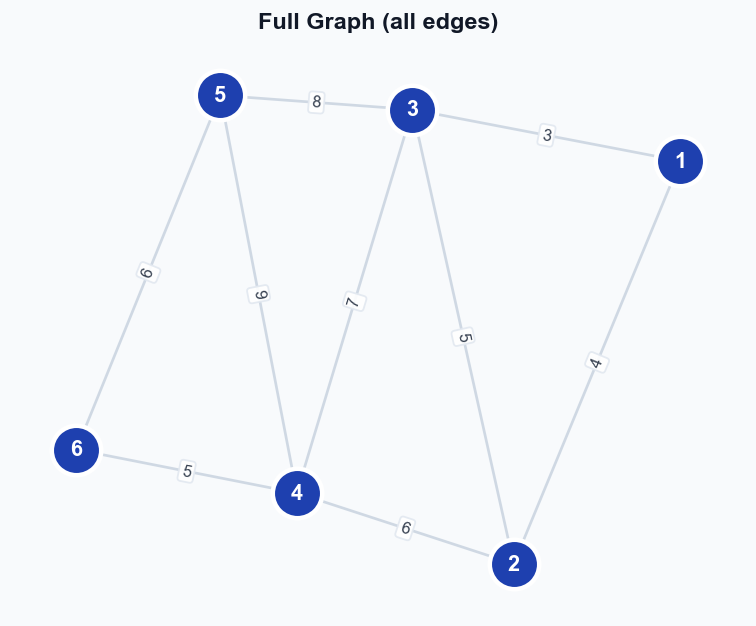

In [6]:
# =========================================================
#  CHART 4 — MST Graph Visualization
# =========================================================
VERTS = [1,2,3,4,5,6]
EDGES = [(1,2,4),(1,3,3),(2,3,5),(2,4,6),(3,4,7),(3,5,8),(4,5,9),(4,6,5),(5,6,6)]

G = nx.Graph(); G.add_nodes_from(VERTS)
for u, v, w in EDGES: G.add_edge(u, v, weight=w)
POS = nx.spring_layout(G, seed=42, k=1.4)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(FIG_BG)
nx.draw_networkx_nodes(G, POS, ax=ax, node_color="#1E40AF", node_size=750, linewidths=2.5, edgecolors="white")
nx.draw_networkx_labels(G, POS, ax=ax, font_color="white", font_size=12, font_weight="bold")
nx.draw_networkx_edges(G, POS, ax=ax, edge_color="#CBD5E1", width=1.5, alpha=0.9)
nx.draw_networkx_edge_labels(G, POS, edge_labels=nx.get_edge_attributes(G,"weight"), ax=ax, font_size=9, font_color="#374151", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#E2E8F0", alpha=0.9))
ax.set_title("Full Graph (all edges)", color="#111827", pad=10)
ax.axis("off")
plt.tight_layout()
plt.show()
